5.Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform following tasks: 1. Pre-process the dataset. 2. Identify outliers. 3. Check the correlation. 4. Implement linear regression and ridge, Lasso regression models. 5. Evaluate the models and compare their respective scores like R2, RMSE, etc.


In [ ]:
import pandas as pd
df=pd.read_csv("/content/uber.csv")
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0
...,...,...,...,...,...,...,...,...,...
71461,48134199,2010-01-08 09:26:05.0000003,4.9,2010-01-08 09:26:05 UTC,0.000000,0.000000,0.000000,0.000000,1.0
71462,26188860,2013-02-26 12:23:36.0000003,7.0,2013-02-26 12:23:36 UTC,-73.956240,40.767923,-73.968175,40.762405,1.0
71463,51156514,2013-10-19 00:03:00.000000251,3.5,2013-10-19 00:03:00 UTC,-73.990945,40.733887,-73.993423,40.729732,5.0
71464,26060919,2009-03-20 22:25:44.0000002,8.6,2009-03-20 22:25:44 UTC,-73.971435,40.748635,-73.955336,40.780232,1.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
df.head()
df.tail()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
71461,48134199,2010-01-08 09:26:05.0000003,4.9,2010-01-08 09:26:05 UTC,0.000000,0.000000,0.000000,0.000000,1.0
71462,26188860,2013-02-26 12:23:36.0000003,7.0,2013-02-26 12:23:36 UTC,-73.956240,40.767923,-73.968175,40.762405,1.0
71463,51156514,2013-10-19 00:03:00.000000251,3.5,2013-10-19 00:03:00 UTC,-73.990945,40.733887,-73.993423,40.729732,5.0
71464,26060919,2009-03-20 22:25:44.0000002,8.6,2009-03-20 22:25:44 UTC,-73.971435,40.748635,-73.955336,40.780232,1.0
71465,24312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [ ]:
df.describe()


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,7.146600e+04,71465.000000,71465.000000,71465.000000,71465.000000,71465.000000,71465.000000
mean,2.770109e+07,11.369363,-72.552753,39.946339,-72.565751,39.944831,1.675995
std,1.601735e+07,9.918296,10.936267,6.391720,10.563282,6.069283,1.297039
min,4.800000e+01,-5.000000,-748.016667,-74.015515,-737.916665,-74.009465,0.000000
25%,1.384615e+07,6.000000,-73.992086,40.734776,-73.991446,40.733673,1.000000
50%,2.765386e+07,8.500000,-73.981821,40.752545,-73.980143,40.752975,1.000000
75%,4.151441e+07,12.500000,-73.967252,40.767110,-73.963777,40.768088,2.000000
max,5.542169e+07,350.000000,40.808425,404.433332,40.828377,45.031598,6.000000


Remove Missing Values

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
key,1
fare_amount,1
pickup_datetime,1
pickup_longitude,1
pickup_latitude,1
dropoff_longitude,1
dropoff_latitude,1
passenger_count,1


In [ ]:
df = df.dropna()
df = df[df['fare_amount'] > 0]

Data Cleaning

Remove Invalid Fare Values

In [ ]:
df=df[df['passenger_count']>0]

Feature Engineering (Distance Calculation)

In [ ]:
df=df[
    (df['pickup_latitude'].between(-90,90))&
    (df['pickup_longitude'].between(-180,180))&
    (df['dropoff_latitude'].between(-90,90))&
    (df['dropoff_longitude'].between(-180,180))
]

In [ ]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

In [ ]:
df['hour']=df['pickup_datetime'].dt.hour
df['day']=df['pickup_datetime'].dt.day
df['month']=df['pickup_datetime'].dt.month

In [ ]:
df.drop(['pickup_datetime', 'key'], axis=1, inplace=True)


Havrsine formula

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    r = 6371
    return c * r


In [ ]:
df['distance'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)


Using Boxplot

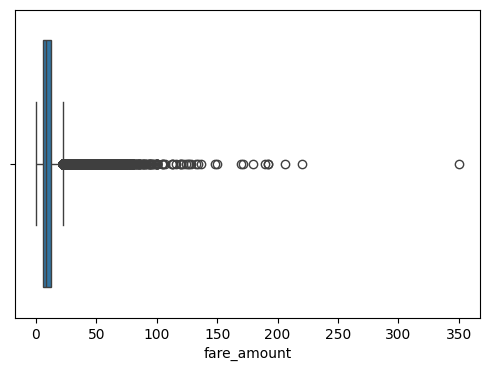

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare_amount'])
plt.show()

Remove Outliers Using IQR Method

In [ ]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['fare_amount'] >= Q1 - 1.5*IQR) &
        (df['fare_amount'] <= Q3 + 1.5*IQR)]


Check Correlation

In [ ]:
df.corr(numeric_only=True)


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,distance
Unnamed: 0,1.000000,0.007086,0.001855,-0.002840,0.001534,-0.001771,0.006986,-0.000376,0.005023,0.000616,-0.002235
fare_amount,0.007086,1.000000,-0.002394,0.002447,-0.002934,0.002929,0.014325,-0.009758,0.011802,0.025737,0.004282
pickup_longitude,0.001855,-0.002394,1.000000,-0.976495,0.953003,-0.939594,0.003913,0.000917,0.003496,-0.008811,0.171456
pickup_latitude,-0.002840,0.002447,-0.976495,1.000000,-0.941598,0.963614,-0.006402,-0.000646,-0.007270,0.009048,-0.138934
dropoff_longitude,0.001534,-0.002934,0.953003,-0.941598,1.000000,-0.979463,0.005102,0.000321,0.002098,-0.006811,0.123435
dropoff_latitude,-0.001771,0.002929,-0.939594,0.963614,-0.979463,1.000000,-0.007144,-0.000163,-0.006028,0.007665,-0.106335
passenger_count,0.006986,0.014325,0.003913,-0.006402,0.005102,-0.007144,1.000000,0.013877,0.002763,0.010682,-0.001698
hour,-0.000376,-0.009758,0.000917,-0.000646,0.000321,-0.000163,0.013877,1.000000,0.006672,-0.007251,-0.008710
day,0.005023,0.011802,0.003496,-0.007270,0.002098,-0.006028,0.002763,0.006672,1.000000,-0.011380,-0.000378
month,0.000616,0.025737,-0.008811,0.009048,-0.006811,0.007665,0.010682,-0.007251,-0.011380,1.000000,-0.004496


In [ ]:
df.corr(method='pearson')



,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,distance
Unnamed: 0,1.000000,0.007086,0.001855,-0.002840,0.001534,-0.001771,0.006986,-0.000376,0.005023,0.000616,-0.002235
fare_amount,0.007086,1.000000,-0.002394,0.002447,-0.002934,0.002929,0.014325,-0.009758,0.011802,0.025737,0.004282
pickup_longitude,0.001855,-0.002394,1.000000,-0.976495,0.953003,-0.939594,0.003913,0.000917,0.003496,-0.008811,0.171456
pickup_latitude,-0.002840,0.002447,-0.976495,1.000000,-0.941598,0.963614,-0.006402,-0.000646,-0.007270,0.009048,-0.138934
dropoff_longitude,0.001534,-0.002934,0.953003,-0.941598,1.000000,-0.979463,0.005102,0.000321,0.002098,-0.006811,0.123435
dropoff_latitude,-0.001771,0.002929,-0.939594,0.963614,-0.979463,1.000000,-0.007144,-0.000163,-0.006028,0.007665,-0.106335
passenger_count,0.006986,0.014325,0.003913,-0.006402,0.005102,-0.007144,1.000000,0.013877,0.002763,0.010682,-0.001698
hour,-0.000376,-0.009758,0.000917,-0.000646,0.000321,-0.000163,0.013877,1.000000,0.006672,-0.007251,-0.008710
day,0.005023,0.011802,0.003496,-0.007270,0.002098,-0.006028,0.002763,0.006672,1.000000,-0.011380,-0.000378
month,0.000616,0.025737,-0.008811,0.009048,-0.006811,0.007665,0.010682,-0.007251,-0.011380,1.000000,-0.004496


In [ ]:
df.corr(method='kendall')


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,distance
Unnamed: 0,1.000000,0.005656,-0.001049,-0.002513,0.002320,0.000897,0.004546,-0.000413,0.003449,0.000558,0.002918
fare_amount,0.005656,1.000000,-0.031781,-0.049808,0.013787,-0.051193,0.015888,0.005189,0.006882,0.017849,0.630403
pickup_longitude,-0.001049,-0.031781,1.000000,0.435600,0.320862,0.198014,-0.012177,-0.008481,-0.003744,-0.002806,-0.055695
pickup_latitude,-0.002513,-0.049808,0.435600,1.000000,0.180812,0.406421,-0.011754,0.010043,-0.001617,-0.000780,-0.005521
dropoff_longitude,0.002320,0.013787,0.320862,0.180812,1.000000,0.400293,-0.011766,-0.018374,-0.002387,-0.004653,0.003425
dropoff_latitude,0.000897,-0.051193,0.198014,0.406421,0.400293,1.000000,-0.008001,0.004599,-0.001685,-0.001537,0.008631
passenger_count,0.004546,0.015888,-0.012177,-0.011754,-0.011766,-0.008001,1.000000,0.027734,0.002319,0.009975,0.007855
hour,-0.000413,0.005189,-0.008481,0.010043,-0.018374,0.004599,0.027734,1.000000,0.005435,-0.004379,0.000838
day,0.003449,0.006882,-0.003744,-0.001617,-0.002387,-0.001685,0.002319,0.005435,1.000000,-0.007805,0.008550
month,0.000558,0.017849,-0.002806,-0.000780,-0.004653,-0.001537,0.009975,-0.004379,-0.007805,1.000000,0.003750


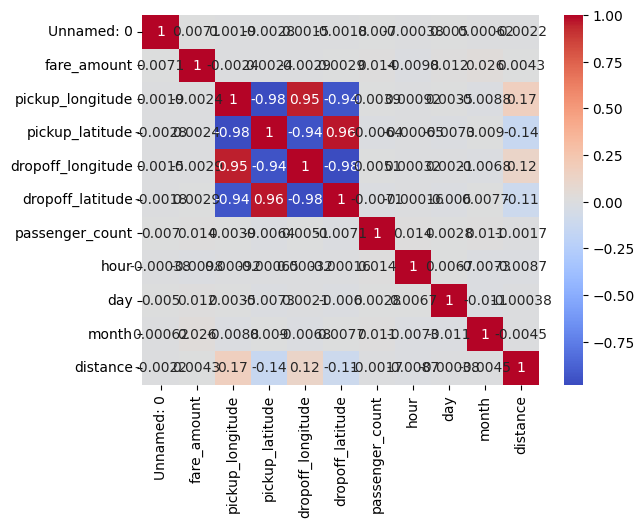

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()



Select Features and Target

In [ ]:
X = df[['distance']]
y = df['fare_amount']




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


Model Evaluation
r2 score

In [ ]:
from sklearn.metrics import r2_score
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))


Linear Regression R2: -0.0005613835082562968


 RMSE

In [ ]:
from sklearn.metrics import mean_squared_error
print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


Linear RMSE: 4.199660151387264


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr))
    ]
})
results


,Model,R2 Score,RMSE
0,Linear Regression,-0.000561,4.19966
